# Figure 3: Benchmark Sweep Overlay

**Paper Figure 3** --- All four coupling measures (binding score, transfer entropy, PAC, CRQA) on a single plot, rank-normalized to [0, 1].

Uses `CouplingBenchmark.sweep()` with the coupled Lorenz system across coupling strengths.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

from att.config import set_seed
from att.synthetic import coupled_lorenz
from att.benchmarks import CouplingBenchmark

rcParams['figure.dpi'] = 150
rcParams['savefig.dpi'] = 300
rcParams['font.size'] = 11
rcParams['font.family'] = 'serif'

In [2]:
set_seed(42)

coupling_values = np.array([0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0])

def lorenz_generator(coupling, seed):
    return coupled_lorenz(n_steps=8000, coupling=coupling, seed=seed)

bench = CouplingBenchmark(
    methods=["binding_score", "transfer_entropy", "pac", "crqa"],
    normalization="rank",
)

print("Running sweep (this may take several minutes)...")
df = bench.sweep(lorenz_generator, coupling_values, seed=42, transient_discard=1000)
print(f"Done. {len(df)} rows.")
df.head(20)

Running sweep (this may take several minutes)...


Done. 40 rows.


,coupling,method,score,score_normalized
0,0.00,binding_score,184.189955,0.333333
1,0.00,transfer_entropy,0.008618,0.111111
2,0.00,pac,0.001885,0.555556
3,0.00,crqa,0.637496,0.555556
4,0.05,binding_score,252.927625,0.888889
5,0.05,transfer_entropy,0.006279,0.000000
6,0.05,pac,0.001406,0.222222
7,0.05,crqa,0.631696,0.333333
8,0.10,binding_score,257.214595,1.000000
9,0.10,transfer_entropy,0.014248,1.000000


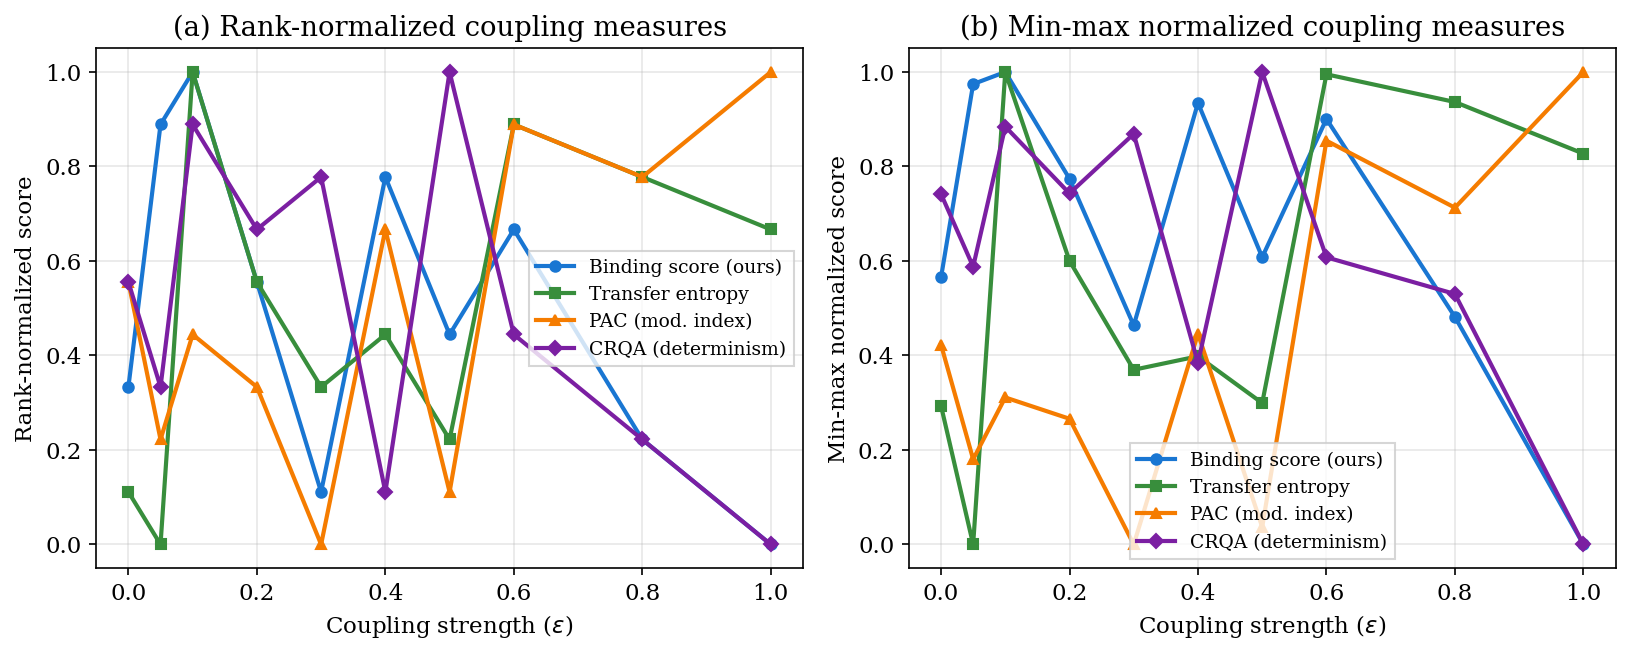

Saved to figures/fig3_benchmark_overlay.{pdf,png}


In [3]:
method_styles = {
    'binding_score': {'color': '#1976D2', 'marker': 'o', 'label': 'Binding score (ours)'},
    'transfer_entropy': {'color': '#388E3C', 'marker': 's', 'label': 'Transfer entropy'},
    'pac': {'color': '#F57C00', 'marker': '^', 'label': 'PAC (mod. index)'},
    'crqa': {'color': '#7B1FA2', 'marker': 'D', 'label': 'CRQA (determinism)'},
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: rank-normalized
ax = axes[0]
for method, style in method_styles.items():
    sub = df[df['method'] == method].sort_values('coupling')
    ax.plot(sub['coupling'], sub['score_normalized'],
            marker=style['marker'], color=style['color'],
            linewidth=2, markersize=5, label=style['label'])
ax.set_xlabel('Coupling strength ($\\epsilon$)')
ax.set_ylabel('Rank-normalized score')
ax.set_title('(a) Rank-normalized coupling measures')
ax.legend(frameon=True, fancybox=False, fontsize=9)
ax.grid(True, alpha=0.3)

# Right: raw scores (separate y-axes would be messy, use minmax instead)
ax = axes[1]
for method, style in method_styles.items():
    sub = df[df['method'] == method].sort_values('coupling')
    vals = sub['score'].values
    vmin, vmax = vals.min(), vals.max()
    rng = vmax - vmin
    normed = (vals - vmin) / rng if rng > 1e-15 else vals * 0
    ax.plot(sub['coupling'], normed,
            marker=style['marker'], color=style['color'],
            linewidth=2, markersize=5, label=style['label'])
ax.set_xlabel('Coupling strength ($\\epsilon$)')
ax.set_ylabel('Min-max normalized score')
ax.set_title('(b) Min-max normalized coupling measures')
ax.legend(frameon=True, fancybox=False, fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('../figures/fig3_benchmark_overlay.pdf', bbox_inches='tight')
fig.savefig('../figures/fig3_benchmark_overlay.png', bbox_inches='tight')
plt.show()
print("Saved to figures/fig3_benchmark_overlay.{pdf,png}")

In [4]:
# Save raw data for the paper
df.to_csv('../figures/fig3_benchmark_data.csv', index=False)
print("Raw data saved to figures/fig3_benchmark_data.csv")

# Print summary table
pivot = df.pivot_table(index='coupling', columns='method', values='score')
print("\nRaw scores:")
print(pivot.round(4).to_string())

Raw data saved to figures/fig3_benchmark_data.csv

Raw scores:
method    binding_score    crqa     pac  transfer_entropy
coupling                                                 
0.00           184.1900  0.6375  0.0019            0.0086
0.05           252.9276  0.6317  0.0014            0.0063
0.10           257.2146  0.6429  0.0017            0.0142
0.20           219.2789  0.6375  0.0016            0.0111
0.30           167.1521  0.6423  0.0010            0.0092
0.40           246.2060  0.6240  0.0019            0.0095
0.50           191.3973  0.6472  0.0011            0.0087
0.60           240.5231  0.6324  0.0027            0.0142
0.80           170.1737  0.6295  0.0025            0.0137
1.00            89.3101  0.6095  0.0030            0.0129
